# IP Utilization of Anycast Prefixes

How many IPs within anycast /24-prefixes are actually active?
Which ASes have high or low utilization, and how does this relate to HRP (Highly Responsive Prefix) status?

In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path
from datetime import datetime

import sys
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent.parent))
from add_ASN import CaidaASLookup
import census_helper

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
import seaborn as sns

plt.style.use('default')
plt.rcParams['axes.labelsize'] = 20
plt.rcParams.update({'font.size': 14})

ts = datetime(2026, 2, 18)

## Data Loading

In [2]:
census_v4 = census_helper.download_date(ts, 'v4')
census_v4 = census_v4[census_v4['GCD_ICMPv4'] > 1]

hrp = pd.read_csv('part-00000-221fd490-deca-4171-ad09-7cf2764b8c5b-c000.csv')
hrp = hrp[hrp['is_hrp']]
census_v4['is_hrp'] = census_v4['prefix'].isin(hrp['prefix'])

print(f"{census_v4['prefix'].nunique():,} /24-prefixes, "
      f"{census_v4[census_v4['is_hrp']]['prefix'].nunique():,} are HRP")

14,346 /24-prefixes, 9,713 are HRP


In [3]:
ip_services = pd.read_csv('part-00000-a6158df2-c124-48da-814d-c180043134fa-c000.csv')
ip_services['/24'] = (
    ip_services['ip'].str.split('.').str[:3].str.join('.') + '.0/24'
)

ip_counts = ip_services.groupby('/24').size()

census_v4['number_of_active_ips'] = (
    census_v4['prefix'].map(ip_counts).fillna(0).astype(int)
)
census_v4['ip_utilization'] = census_v4['number_of_active_ips'] / 256

print(f"{ip_services['ip'].nunique():,} unique active IPs across "
      f"{ip_services['/24'].nunique():,} /24-prefixes")

1,769,803 unique active IPs across 13,233 /24-prefixes


## IP Utilization per AS

In [4]:
census_v4_exploded = census_v4.assign(ASN=census_v4['ASN'].str.split('_')).explode('ASN')

asn_table = (
    census_v4_exploded
    .groupby('ASN')
    .agg(
        active_ips=('number_of_active_ips', 'sum'),
        hrp_count=('is_hrp', 'sum'),
        slash24s=('prefix', 'count'),
    )
)

asn_table['IP Utilization'] = asn_table['active_ips'] / (asn_table['slash24s'] * 256)
asn_table['HRP'] = asn_table['hrp_count'] / asn_table['slash24s']
asn_table = asn_table.drop(columns='hrp_count').reset_index()
asn_table = asn_table.sort_values('active_ips', ascending=False)

asn_table.head(10)

,ASN,active_ips,slash24s,IP Utilization,HRP
64,13335,657528,2866,0.896186,0.989184
666,396982,491593,4298,0.446786,0.973476
915,54113,209398,827,0.989070,0.990326
158,16509,133371,1603,0.325003,0.259513
322,209242,59549,270,0.861531,0.966667
749,40509,22113,223,0.387349,1.000000
695,398787,16383,64,0.999939,1.000000
97,139341,12997,118,0.430250,0.805085
31,12008,11514,98,0.458945,0.448980
154,15967,11173,195,0.223818,0.958974


In [5]:
latex_table = asn_table.sort_values('active_ips', ascending=False).head(10).to_latex(
    index=False, float_format='%.3f'
)
print(latex_table)

\begin{tabular}{lrrrr}
\toprule
ASN & active_ips & slash24s & IP Utilization & HRP \\
\midrule
13335 & 657528 & 2866 & 0.896 & 0.989 \\
396982 & 491593 & 4298 & 0.447 & 0.973 \\
54113 & 209398 & 827 & 0.989 & 0.990 \\
16509 & 133371 & 1603 & 0.325 & 0.260 \\
209242 & 59549 & 270 & 0.862 & 0.967 \\
40509 & 22113 & 223 & 0.387 & 1.000 \\
398787 & 16383 & 64 & 1.000 & 1.000 \\
139341 & 12997 & 118 & 0.430 & 0.805 \\
12008 & 11514 & 98 & 0.459 & 0.449 \\
15967 & 11173 & 195 & 0.224 & 0.959 \\
\bottomrule
\end{tabular}



## AS Counts (IPv4 + IPv6)

In [6]:
all_asns_v4 = census_v4['ASN'].str.split('_').explode()

census_v6 = census_helper.download_date(ts, 'v6')
census_v6 = census_v6[census_v6['GCD_ICMPv6'] > 1]

all_asns_v6 = census_v6['ASN'].str.split('_').explode()

all_unique = pd.concat([all_asns_v4, all_asns_v6]).unique()
overlap = set(all_asns_v4) & set(all_asns_v6)

print(f'IPv4 ASes: {all_asns_v4.nunique():,}')
print(f'IPv6 ASes: {all_asns_v6.nunique():,}')
print(f'Combined:  {len(all_unique):,}')
print(f'Overlap:   {len(overlap):,}')
print(f'IPv6 /48-prefixes: {census_v6["prefix"].nunique():,}')

IPv4 ASes: 1,075
IPv6 ASes: 579
Combined:  1,223
Overlap:   431
IPv6 /48-prefixes: 13,007


In [7]:
import requests

AS_NAME_OVERRIDES = {
    '13335': 'Cloudflare', '15169': 'Google', '20940': 'Akamai',
    '16509': 'AWS', '32934': 'Meta', '8075': 'Microsoft',
}

def get_as_name(asn):
    asn = str(asn).strip()
    if asn in AS_NAME_OVERRIDES:
        return AS_NAME_OVERRIDES[asn]
    try:
        r = requests.get(f'https://stat.ripe.net/data/as-names/data.json?resource=AS{asn}', timeout=5)
        names = r.json()['data']['names']
        name = names.get(f'AS{asn}') or names.get(asn) or asn
        return name if len(name) <= 20 else name[:18] + '..'
    except:
        return f'AS{asn}'

top10_v6 = (
    census_v6.groupby('ASN')['prefix'].nunique()
    .sort_values(ascending=False).head(10)
    .reset_index().rename(columns={'prefix': 'num_prefixes'})
)

total_v6_pfx = census_v6['prefix'].nunique()

rows = ''
for _, row in top10_v6.iterrows():
    asn = str(row['ASN']).strip()
    name = get_as_name(asn)
    n = row['num_prefixes']
    pct = round(n / total_v6_pfx * 100, 1)
    rows += f'        {name} ({asn}) & \\num{{{n}}} & ({pct}\\%) \\\\\n'

latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{l r@{{~}}l}}
        \\toprule
        Org (ASN) & \\multicolumn{{2}}{{c}}{{/48-Prefixes}} \\\\
        \\midrule
{rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\\num{{{total_v6_pfx}}}).}}
    \\label{{tab:top_ases_v6}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{l r@{~}l}
        \toprule
        Org (ASN) & \multicolumn{2}{c}{/48-Prefixes} \\
        \midrule
        CLOUDFLARESPECTRUM.. (209242) & \num{6421} & (49.4\%) \\
        WEN-NET RUNNAN WEN (214040) & \num{1795} & (13.8\%) \\
        FASTLY - Fastly, I.. (54113) & \num{760} & (5.8\%) \\
        Cloudflare (13335) & \num{620} & (4.8\%) \\
        INCAPSULA - Incaps.. (19551) & \num{587} & (4.5\%) \\
        AKAMAI-AMS Akamai .. (33905) & \num{409} & (3.1\%) \\
        AS-AFILIAS1 - Afil.. (12041) & \num{228} & (1.8\%) \\
        AWS (16509) & \num{186} & (1.4\%) \\
        GODADDY-DNS Host E.. (44273) & \num{124} & (1.0\%) \\
        AS399153_399155_399164_399161_399169_399170 (399153_399155_399164_399161_399169_399170) & \num{108} & (0.8\%) \\
        \bottomrule
    \end{tabular}
    \caption{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\num{13007}).}
    \label{tab:top_ases_v6}
\end{table}


## IP Utilization and HRP Distribution

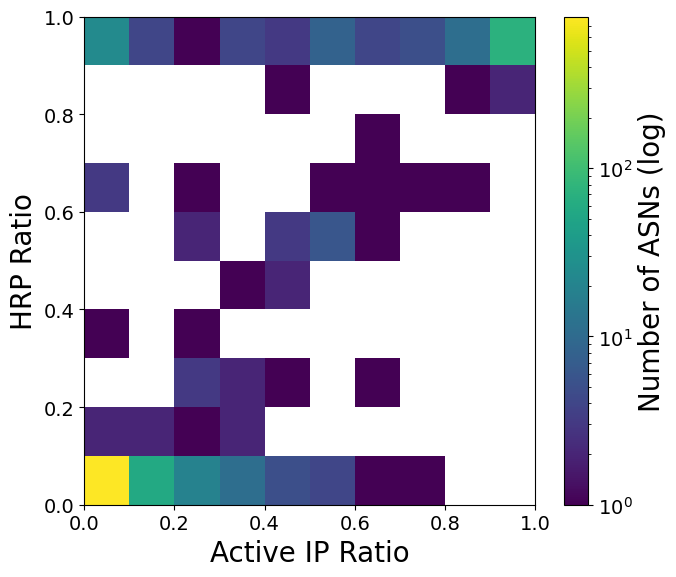

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

x_bins = np.linspace(0, 1, 11)
y_bins = np.linspace(0, 1, 11)
hist = ax.hist2d(asn_table['IP Utilization'], asn_table['HRP'], bins=[x_bins, y_bins], norm=LogNorm())
ax.set_xlabel('Active IP Ratio')
ax.set_ylabel('HRP Ratio')
fig.colorbar(hist[3], ax=ax).set_label('Number of ASNs (log)')

plt.tight_layout()
plt.savefig('ip_utilization.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [9]:
high_util = asn_table[asn_table['IP Utilization'] > 0.66]
low_util  = asn_table[asn_table['IP Utilization'] <= 0.33]

print(f'High utilization (>66%): {len(high_util)} ASes')
print(f'Low utilization  (<=33%): {len(low_util)} ASes')
print(f'Low util + high HRP: {len(asn_table[(asn_table["IP Utilization"] < 0.33) & (asn_table["HRP"] > 0.66)])} ASes')
print(f'High util + low HRP: {len(asn_table[(asn_table["IP Utilization"] > 0.66) & (asn_table["HRP"] < 0.33)])} ASes')

High utilization (>66%): 97 ASes
Low utilization  (<=33%): 922 ASes
Low util + high HRP: 31 ASes
High util + low HRP: 2 ASes


## Geographic Deployment

Where do anycast operators deploy? We assign each anycast location to a UN subregion
and normalize by population.

In [10]:
import geopandas as gpd

# Explode locations
census_v4_locs = census_v4.copy()
census_v4_locs['locations'] = census_v4_locs['locations'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
census_v4_locs = census_v4_locs.explode('locations')
census_v4_locs['lat'] = census_v4_locs['locations'].apply(lambda x: x['lat'])
census_v4_locs['lon'] = census_v4_locs['locations'].apply(lambda x: x['lon'])

# Load world map
url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip'
world = gpd.read_file(url)
if 'ADM0_A3' in world.columns:
    world = world.rename(columns={'ADM0_A3': 'iso_a3'})
world = world[world['iso_a3'] != 'ATA']

# Spatial join
points = gpd.GeoDataFrame(
    census_v4_locs,
    geometry=gpd.points_from_xy(census_v4_locs['lon'], census_v4_locs['lat']),
    crs='EPSG:4326'
)
joined = gpd.sjoin(points, world[['geometry', 'SUBREGION']], how='left', predicate='within')
joined_exploded = joined.assign(ASN=joined['ASN'].str.split('_')).explode('ASN')

region_stats = joined_exploded.groupby('SUBREGION')['ASN'].nunique().reset_index(name='unique_ases')

In [11]:
import requests, io

# Download UN WPP 2024 population estimates
pop_url = 'https://population.un.org/wpp/assets/Excel%20Files/1_Indicator%20(Standard)/CSV_FILES/WPP2024_TotalPopulationBySex.csv.gz'
r = requests.get(pop_url, timeout=30)
un_pop = pd.read_csv(io.BytesIO(r.content), compression='gzip')

un_pop_2025 = un_pop[
    (un_pop['Time'] == 2025) & (un_pop['Variant'] == 'Medium') & (un_pop['LocTypeID'] == 4)
][['ISO3_code', 'PopTotal']].copy()
un_pop_2025['population'] = un_pop_2025['PopTotal'] * 1000

world_pop = world.merge(un_pop_2025[['ISO3_code', 'population']],
                        left_on='iso_a3', right_on='ISO3_code', how='left')

pop_by_region = world_pop.groupby('SUBREGION')['population'].sum().reset_index(name='population')

region_map = world.dissolve(by='SUBREGION')
region_map = region_map.merge(region_stats, on='SUBREGION', how='left')
region_map = region_map.merge(pop_by_region, on='SUBREGION', how='left')
region_map['unique_ases'] = region_map['unique_ases'].fillna(0)
region_map['ases_per_million'] = region_map['unique_ases'] / (region_map['population'] / 1_000_000)

print(f"Countries matched: {un_pop_2025['ISO3_code'].isin(world['iso_a3']).sum()} / {len(un_pop_2025)}")

/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_91667/3299890650.py:6: DtypeWarning: Columns (0: Notes, 1: ISO3_code, 2: ISO2_code, 3: LocTypeName) have mixed types. Specify dtype option on import or set low_memory=False.
  un_pop = pd.read_csv(io.BytesIO(r.content), compression='gzip')


Countries matched: 226 / 237


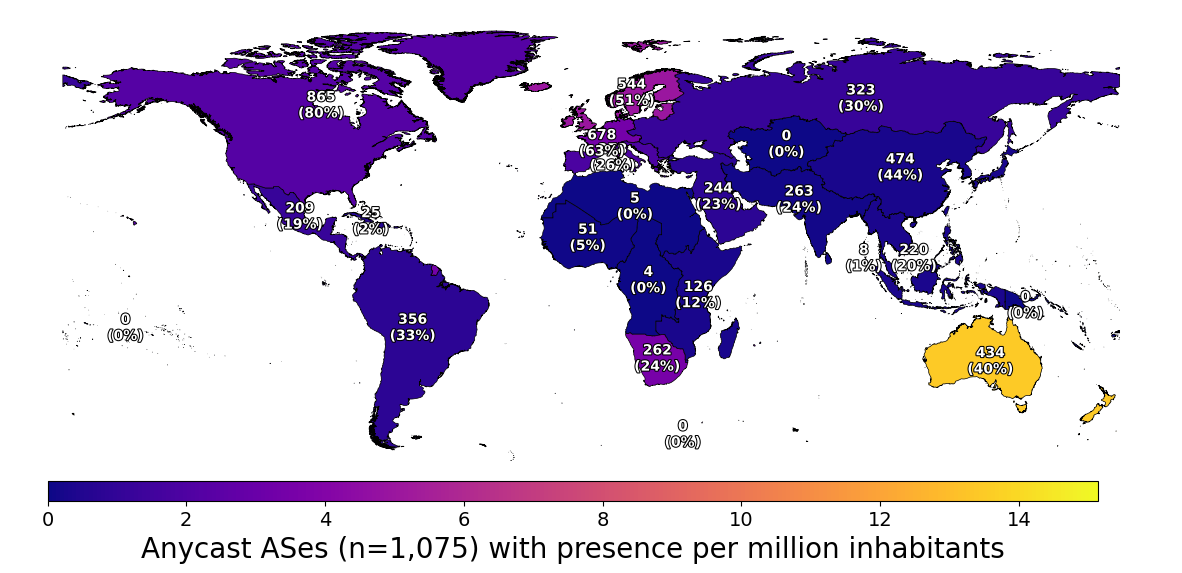

In [12]:
total_ases = joined_exploded['ASN'].nunique()

offsets = {
    'Western Europe': (2, 3),
    'Southern Europe': (5, -4),
    'Micronesia': (65, 5),
}

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
region_map.plot(
    column='ases_per_million', ax=ax, cmap='plasma',
    edgecolor='black', linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)

for idx, row in region_map.iterrows():
    if pd.isna(row.get('unique_ases')) or idx == 'Seven seas (open ocean)':
        continue
    centroid = row['geometry'].centroid
    n = int(row['unique_ases'])
    pct = round(n / total_ases * 100)
    dx, dy = offsets.get(idx, (0, 0))
    ax.text(centroid.x + dx, centroid.y + dy,
            f'{n}\n({pct}%)', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

cax = fig.add_axes([0.15, 0.24, 0.7, 0.02])
sm = plt.cm.ScalarMappable(cmap='plasma',
    norm=plt.Normalize(vmin=region_map['ases_per_million'].min(),
                       vmax=region_map['ases_per_million'].max()))
fig.colorbar(sm, cax=cax, orientation='horizontal',
             label=f'Anycast ASes (n={total_ases:,}) with presence per million inhabitants')
ax.set_axis_off()
plt.savefig('map_subregion_heatmap_per_capita.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [13]:
def plot_map(col, label, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    norm = LogNorm(vmin=max(region_map[col].min(), 0.01), vmax=region_map[col].max())
    region_map.plot(column=col, ax=ax, cmap='plasma', norm=norm,
                    edgecolor='black', linewidth=0.5,
                    missing_kwds={'color': 'lightgrey'})
    cax = fig.add_axes([0.15, 0.12, 0.7, 0.02])
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
    fig.colorbar(sm, cax=cax, orientation='horizontal', label=label)
    ax.set_axis_off()
    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f'Saved {filename}')

plot_map('unique_ases',
         f'Anycast ASes per subregion (n={int(region_map["unique_ases"].sum())})',
         'map_absolute.pdf')

plot_map('ases_per_million',
         'Anycast ASes per million people (UN WPP 2025)',
         'map_normalized.pdf')

Saved map_absolute.pdf
Saved map_normalized.pdf


## Regional Classification

Classify each anycast prefix as **Global** (multi-continent), **Continental** (single continent),
or **National** (single country) based on its geolocated PoP distribution.

In [14]:
import reverse_geocoder as rg
import pycountry_convert as pc


def classify_anycast_fast(df):
    def clean_loc(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, str):
            try: return ast.literal_eval(x)
            except: return []
        return x if isinstance(x, list) else []

    df['clean_locations'] = df['locations'].apply(clean_loc)
    df = df.reset_index().rename(columns={'index': 'original_id'})

    df_exploded = df.explode('clean_locations').dropna(subset=['clean_locations'])
    coords_df = pd.DataFrame(df_exploded['clean_locations'].tolist())
    coords_df['lat'] = pd.to_numeric(coords_df['lat'], errors='coerce')
    coords_df['lon'] = pd.to_numeric(coords_df['lon'], errors='coerce')

    valid = coords_df.dropna(subset=['lat', 'lon']).index
    df_exploded = df_exploded.iloc[valid].copy()
    df_exploded['lat'] = coords_df.loc[valid, 'lat'].values
    df_exploded['lon'] = coords_df.loc[valid, 'lon'].values

    unique_coords = df_exploded[['lat', 'lon']].drop_duplicates()
    coords_tuple = list(zip(unique_coords['lat'], unique_coords['lon']))
    if not coords_tuple:
        return df

    print(f'Batch geocoding {len(coords_tuple)} unique locations...')
    geo_results = rg.search(coords_tuple, verbose=False)

    geo_df = pd.DataFrame(geo_results)
    geo_df['lat'] = unique_coords['lat'].values
    geo_df['lon'] = unique_coords['lon'].values
    geo_df = geo_df[['lat', 'lon', 'cc']]

    continent_map = {}
    for cc in geo_df['cc'].unique():
        try:
            continent_map[cc] = pc.country_alpha2_to_continent_code(cc)
        except:
            continent_map[cc] = 'Unknown'
    geo_df['continent'] = geo_df['cc'].map(continent_map)

    merged = df_exploded.merge(geo_df, on=['lat', 'lon'], how='left')

    stats = merged.groupby('original_id').agg(
        unique_countries=('cc', 'nunique'),
        unique_continents=('continent', 'nunique'),
        continent=('continent', lambda x: x.iloc[0] if x.nunique() == 1 else None),
        country=('cc', lambda x: x.iloc[0] if x.nunique() == 1 else None)
    )

    conditions = [
        (stats['unique_continents'] > 1),
        (stats['unique_countries'] > 1)
    ]
    stats['scope'] = np.select(conditions, ['Global', 'Continental'], default='National')

    df_clean = df.set_index('original_id').drop(columns=['scope', 'continent', 'country'], errors='ignore')
    final_df = df_clean.join(stats[['scope', 'continent', 'country']], how='left')
    final_df['scope'] = final_df['scope'].fillna('Unknown')
    return final_df


anycast_df_processed = classify_anycast_fast(census_v4)
anycast_df_processed['scope'].value_counts()

Batch geocoding 268 unique locations...


scope
Global         13135
National         769
Continental      442
Name: count, dtype: int64

In [15]:
import pycountry

def nunique_ases(s):
    return s.str.split('_').explode().nunique()

total_ases     = nunique_ases(anycast_df_processed['ASN'])
total_prefixes = anycast_df_processed['prefix'].nunique()

global_df    = anycast_df_processed[anycast_df_processed['scope'] == 'Global']
regional_df  = anycast_df_processed[anycast_df_processed['scope'].isin(['Continental', 'National'])]
national_df_ = anycast_df_processed[anycast_df_processed['scope'] == 'National']

n_global_ases    = nunique_ases(global_df['ASN'])
n_global_pfx     = global_df['prefix'].nunique()
n_regional_ases  = nunique_ases(regional_df['ASN'])
n_regional_pfx   = regional_df['prefix'].nunique()
n_national_ases  = nunique_ases(national_df_['ASN'])
n_national_pfx   = national_df_['prefix'].nunique()

continent_stats = (
    regional_df.groupby('continent')
    .agg(num_ases=('ASN', nunique_ases), num_prefixes=('prefix', 'nunique'))
    .sort_values('num_ases', ascending=False)
)

country_stats = (
    national_df_.groupby('country')
    .agg(num_ases=('ASN', nunique_ases), num_prefixes=('prefix', 'nunique'))
    .sort_values('num_ases', ascending=False)
)

continent_name_map = {
    'NA': 'North America', 'EU': 'Europe', 'AS': 'Asia',
    'OC': 'Oceania', 'SA': 'South America', 'AF': 'Africa',
}

def cc_to_country_name(cc):
    try: return pycountry.countries.get(alpha_2=cc).name
    except: return cc

def fmt(n, denom):
    pct = round(n / denom * 100)
    return f'\\num{{{n}}}', f'({pct}\\%)'

def make_row(label, n_ases, denom_ases, n_pfx, denom_pfx):
    a_num, a_pct = fmt(n_ases, denom_ases)
    p_num, p_pct = fmt(n_pfx, denom_pfx)
    return f'        {label:<35} & {a_num} & {a_pct} & {p_num} & {p_pct} \\\\\n'

continent_rows = ''.join(
    make_row(f'\\quad {continent_name_map.get(cc, cc)}',
             r['num_ases'], n_regional_ases, r['num_prefixes'], n_regional_pfx)
    for cc, r in continent_stats.iterrows()
)

country_rows = ''.join(
    make_row(f'\\quad {cc_to_country_name(cc)}',
             r['num_ases'], n_national_ases, r['num_prefixes'], n_national_pfx)
    for cc, r in country_stats.iterrows()
)

latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{l r@{{~}}l r@{{~}}l}}
        \\toprule
        Deployment Scope & \\multicolumn{{2}}{{c}}{{ASes}} & \\multicolumn{{2}}{{c}}{{/24-Prefixes}} \\\\
        \\midrule
{make_row('Global (multi-continent)', n_global_ases, total_ases, n_global_pfx, total_prefixes)}\
{make_row('Single continent', n_regional_ases, total_ases, n_regional_pfx, total_prefixes)}\
{make_row('\\\\quad Single country', n_national_ases, total_ases, n_national_pfx, total_prefixes)}\
        \\midrule
        \\multicolumn{{5}}{{l}}{{\\textit{{Single-continent deployments by region (n=\\num{{{n_regional_ases}}})}}}} \\\\
        \\midrule
{continent_rows}        \\midrule
        \\multicolumn{{5}}{{l}}{{\\textit{{Single-country deployments by country (n=\\num{{{n_national_ases}}})}}}} \\\\
        \\midrule
{country_rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Regional deployment scope of ASes (n=\\num{{{total_ases}}}) with IPv4 anycast /24-prefixes (n=\\num{{{total_prefixes}}}) observed by \\laces.}}
    \\label{{tab:anycast_regional}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{l r@{~}l r@{~}l}
        \toprule
        Deployment Scope & \multicolumn{2}{c}{ASes} & \multicolumn{2}{c}{/24-Prefixes} \\
        \midrule
        Global (multi-continent)            & \num{794} & (74\%) & \num{13135} & (92\%) \\
        Single continent                    & \num{381} & (35\%) & \num{1211} & (8\%) \\
        \\quad Single country               & \num{245} & (23\%) & \num{769} & (5\%) \\
        \midrule
        \multicolumn{5}{l}{\textit{Single-continent deployments by region (n=\num{381})}} \\
        \midrule
        \quad North America                 & \num{196} & (51\%) & \num{724} & (60\%) \\
        \quad Europe                        & \num{119} & (31\%) & \num{223} & (18\%) \\
        \quad Asia                          & \num{51} & (13\%) & \num{128} & (11\%) \\
        \quad Oceania                       & \num{46} & (12\%) & \num{122} & (10\%) \\
        \quad South America                 & \num{10} & (3\%) & \num{12

## Multi-Continent Regional Deployments

In [16]:
multi_continent_ases = (
    regional_df[regional_df['continent'] != 'Unknown']
    .groupby('ASN')['continent']
    .agg(lambda x: sorted(x.unique()))
    .reset_index()
)
multi_continent_ases['n_continents'] = multi_continent_ases['continent'].apply(len)
multi_continent_ases = (
    multi_continent_ases[multi_continent_ases['n_continents'] > 1]
    .sort_values('n_continents', ascending=False)
    .reset_index(drop=True)
)

print(f'ASes with regional anycast in multiple continents: {len(multi_continent_ases)}')
multi_continent_ases

ASes with regional anycast in multiple continents: 23


,ASN,continent,n_continents
0,16509,"[AS, EU, NA, OC, SA]",5
1,200325,"[AS, NA, OC, SA]",4
2,33905,"[AS, EU, NA, OC]",4
3,23013,"[AS, EU, NA]",3
4,199524,"[AS, EU, NA]",3
5,20473,"[AS, NA, OC]",3
6,40934,"[AS, EU, NA]",3
7,396986,"[AS, EU, NA]",3
8,13150,"[AS, EU, NA]",3
9,3356,"[EU, NA]",2


In [ ]:
# Per-AS per-continent prefix counts
asn_continent_pfx = (
    regional_df[regional_df['continent'] != 'Unknown']
    .groupby(['ASN', 'continent'])['prefix']
    .nunique()
    .reset_index()
    .rename(columns={'prefix': 'num_prefixes'})
)

asn_continent_pfx['AS Name'] = asn_continent_pfx['ASN'].apply(get_as_name)

pivot = asn_continent_pfx.pivot_table(
    index=['ASN', 'AS Name'], columns='continent',
    values='num_prefixes', fill_value=0
).reset_index()

pivot['total'] = pivot.select_dtypes(include='number').sum(axis=1)
pivot = pivot.sort_values('total', ascending=False)
pivot.head(20)

In [ ]:
regional_df.to_csv('regional_prefixes.csv.gz', index=False)
print(f'Exported {len(regional_df)} regional prefixes')